In [1]:
from sklearn.datasets import load_iris

In [2]:
iris = load_iris()
# print(iris)

In [3]:
X = iris.data
y = iris.target

In [4]:
X.shape

(150, 4)

<Axes: >

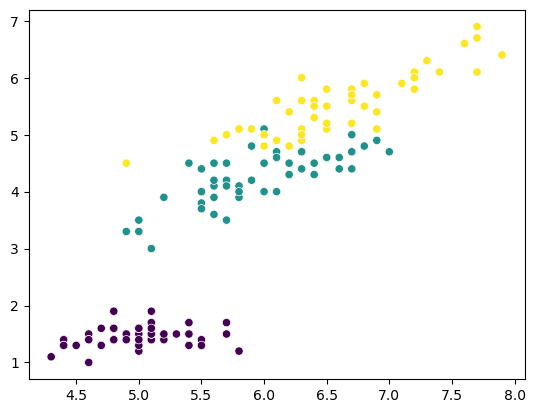

In [5]:
# vizualization

import seaborn as sns
sns.scatterplot(
    x=X[:,0],
    y=X[:,2],
    c=y
)

In [6]:
# scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
# X_scaled

In [ ]:
# optional dimesionality reduction using using PCA

# from sklearn.decomposition import PCA

# pca = PCA(n_components=2)         # we only want 2 features in the end

# pca_data = pca.fit_transform(X_scaled)

In [7]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# Elbow method to find k value
from sklearn.cluster import KMeans

wcss=[]
for k in range(1,21):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X_scaled)      # kmeans.fit_predict(pca_data)
    wcss.append(kmeans.inertia_)


from kneed import KneeLocator
knee = KneeLocator( range(1,21), wcss, curve='convex', direction='decreasing' )
print(knee.knee)

3


<Axes: >

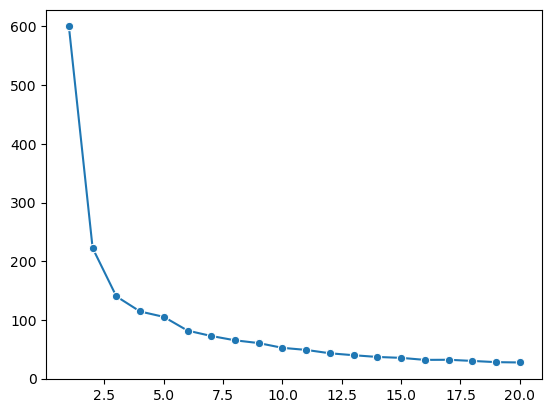

In [8]:
sns.lineplot(
    x=range(1,21),
    y=wcss,
    marker='o'
)

<Axes: >

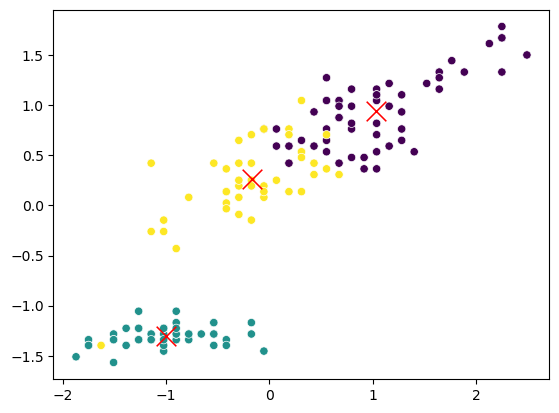

In [9]:
# model kmeans

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=10)
labels = kmeans.fit_predict(X_scaled)         # kmeans.fit_predict(pca_data)

sns.scatterplot(
    x=X_scaled[:,0],
    y=X_scaled[:,2],           # y=X[:,1] because we only have two columns
    c=labels
)

sns.scatterplot(
    x=kmeans.cluster_centers_[:,0],
    y=kmeans.cluster_centers_[:,2],
    marker="x",
    c="red",
    s=200
)